The following diagram comes from
https://zhuanlan.zhihu.com/p/342261872

In the original paper, the model was pretrained on 224x224 images and later finetuned on 384x384 images. Please do remmember that they provide both 16x16 and 32x32 patch-size versions. so in the pretraining stage, there are (224/16)×(224/16)=14×14=196 patches. In the following figure 9 patches are just for better describing the overall idea.

In this code example, the image size is 72x72 and each patch is 6x6

The original paper is **AN IMAGE IS WORTH 16X16 WORDS: TRANSFORMERS FOR IMAGE RECOGNITION AT SCALE** but its experiments also involves using 32*32.

code reference: https://github.com/nathanwbailey/vision_transformer


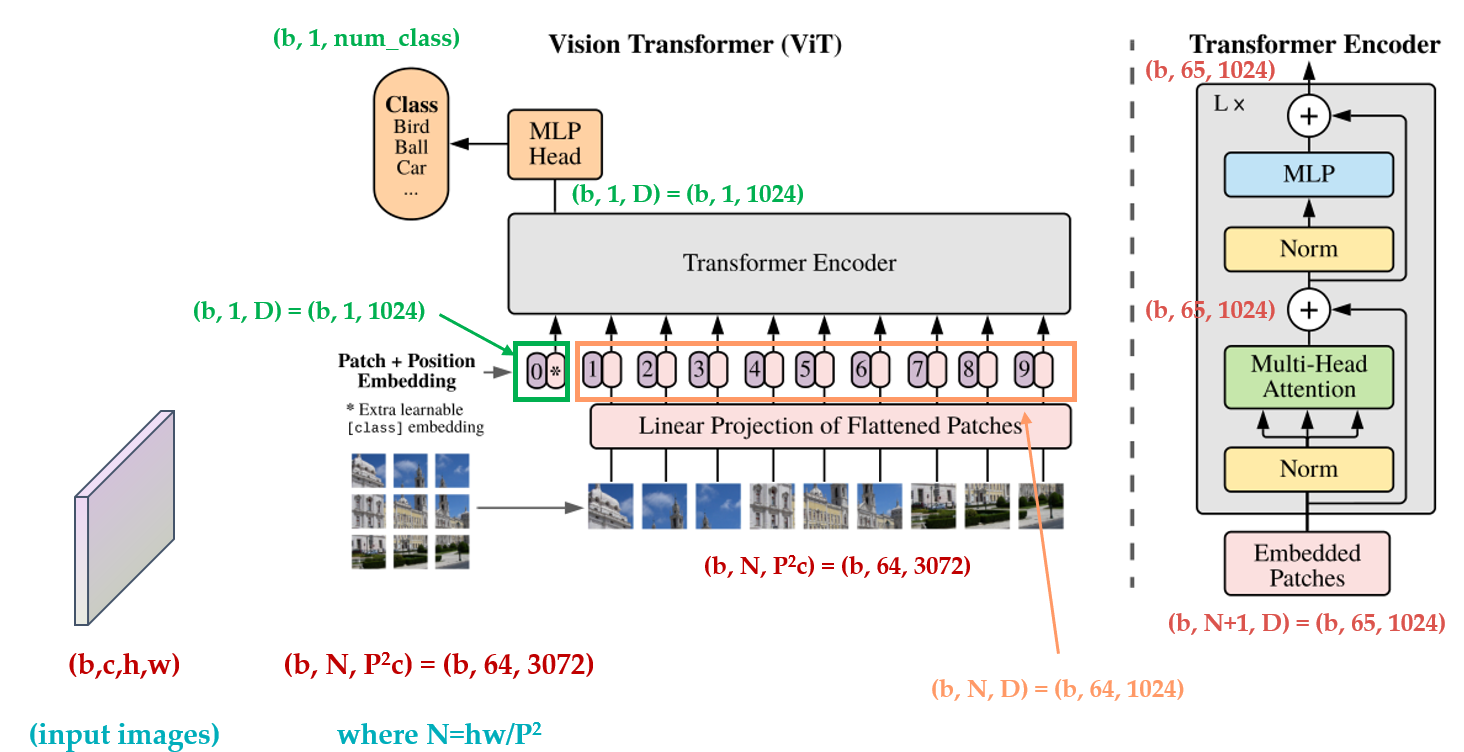

In [ ]:
!pip install pytorch-model-summary
import pytorch_model_summary as pms
import torch
import torchvision

#from model import ViTClassifierModel
#from train import test_network, train_network

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001
BATCH_SIZE = 32
NUM_EPOCHS = 10 #100
IMAGE_SIZE = 72
PATCH_SIZE = 6
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 8
MLP_HEAD_UNITS = [2048, 1024]

transforms = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor()]
)

train_dataset = torchvision.datasets.CIFAR100(
    root="./data", train=True, download=True, transform=transforms
)

trainloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=4,
)

mean = torch.zeros(3).to(DEVICE)
std = torch.zeros(3).to(DEVICE)

for idx, batch in enumerate(trainloader):
    image = batch[0].to(DEVICE)
    image_mean = torch.mean(image, dim=(0, 2, 3))
    image_std = torch.std(image, dim=(0, 2, 3))
    mean = torch.add(mean, image_mean)
    std = torch.add(std, image_std)

mean = (mean / len(trainloader)).to("cpu")
std = (std / len(trainloader)).to("cpu")

print(mean)
print(std)

train_transforms = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        torchvision.transforms.RandomRotation(degrees=7),
        torchvision.transforms.RandomHorizontalFlip(p=0.5),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean, std),
    ]
)

test_transforms = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean, std),
    ]
)

train_dataset = torchvision.datasets.CIFAR100(
    root="./data", train=True, download=True, transform=train_transforms
)

valid_dataset = torchvision.datasets.CIFAR100(
    root="./data", train=False, download=True, transform=test_transforms
)

valid_set, test_set = torch.utils.data.random_split(
    valid_dataset, [0.7, 0.3], generator=torch.Generator().manual_seed(42)
)

trainloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=4,
    drop_last=True,
)
validloader = torch.utils.data.DataLoader(
    valid_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    drop_last=True,
)
testloader = torch.utils.data.DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    drop_last=True,
)


tensor([0.5071, 0.4865, 0.4409])
tensor([0.2654, 0.2547, 0.2740])


**Model building blocks:**

In [ ]:
from typing import Type

import torch


class CreatePatchesLayer(torch.nn.Module):
    """Custom PyTorch Layer to Extract Patches from Images."""

    def __init__(
        self,
        patch_size: int,
        strides: int,
    ) -> None:
        """Init Variables."""
        super().__init__()
        self.unfold_layer = torch.nn.Unfold(
            kernel_size=patch_size, stride=strides
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        """Forward Pass to Create Patches."""
        patched_images = self.unfold_layer(images) # (Batch Size, (P²)*C, Number of Patches)

        return patched_images.permute((0, 2, 1)) #  (Batch Size, Number of Patches, (P²)*C)


class PatchEmbeddingLayer(torch.nn.Module):
    """Positional Embedding Layer for Images of Patches."""

    def __init__(
        self,
        num_patches: int,
        batch_size: int,
        patch_size: int,
        embed_dim: int,
        device: torch.device,
        num_added_token: int = 1,
    ) -> None:
        """Init Function."""
        super().__init__()
        self.num_patches = num_patches
        self.patch_size = patch_size
        self.num_added_token = num_added_token
        # Alex: this is not learnable and
        self.position_emb = torch.nn.Embedding(
            num_embeddings=num_patches + num_added_token, embedding_dim=embed_dim # Alex: the "+1" is the positional embedding of self.class_parameter
        )
        # Alex: remember that for a fc layer, every batch would be processed in the same way so there is no batch of it.
        # i.e., its size shouldn't be batch*(patch_size * patch_size * 3)*embed_dim
        self.projection_layer = torch.nn.Linear(
            patch_size * patch_size * 3, embed_dim
        )
        # Alex: This is learnable and is designed to help Transformer encoding understand every input image.
        # Actually, this is the classification embedding and its corresponding output would be fed into the MLP classification layer
        # self.class_parameter = torch.nn.Parameter(
        #     torch.rand(batch_size, 1, embed_dim).to(device), #1
        #     requires_grad=True,
        # )
        self.class_parameter = torch.nn.Parameter(
            torch.rand(batch_size, num_added_token, embed_dim).to(device),
            requires_grad=True,
        )
        self.device = device

    def forward(self, patches: torch.Tensor) -> torch.Tensor:
        """Forward Pass."""

        positions = (
            torch.arange(start=0, end=self.num_patches + self.num_added_token, step=1) # Alex: the "+1" is the positional embedding of self.class_parameter
            .to(self.device)
            .unsqueeze(dim=0)
        )
        # patches: (Batch Size, Number of Patches, (P²)*C)
        patches = self.projection_layer(patches)
        # patches: (Batch Size, Number of Patches, embed_dim)
        # Alex: Please remind that the class_parameter is the 1st embedding.
        encoded_patches = torch.cat(
            (self.class_parameter, patches), dim=1
        ) + self.position_emb(positions)

        # Alex: put self.class_parameter at the end
        # encoded_patches = torch.cat(
        #     (patches, self.class_parameter), dim=1
        # ) + self.position_emb(positions)


        return encoded_patches


def create_mlp_block(
    input_features: int,
    output_features: list[int],
    activation_function: Type[torch.nn.Module],
    dropout_rate: float,
) -> torch.nn.Module:
    """Create a Feed Forward Network for the Transformer Layer."""
    layer_list = []
    for idx in range(  # pylint: disable=consider-using-enumerate
        len(output_features)
    ):
        if idx == 0:
            linear_layer = torch.nn.Linear(
                in_features=input_features, out_features=output_features[idx]
            )
        else:
            linear_layer = torch.nn.Linear(
                in_features=output_features[idx - 1],
                out_features=output_features[idx],
            )
        dropout = torch.nn.Dropout(p=dropout_rate)
        layers = torch.nn.Sequential(
            linear_layer, activation_function(), dropout
        )
        layer_list.append(layers)
    return torch.nn.Sequential(*layer_list)


class TransformerBlock(torch.nn.Module):
    """Transformer Block Layer."""

    def __init__(
        self,
        num_heads: int, #Alex:４
        key_dim: int, #Alex 64
        embed_dim: int, #Alex 64
        ff_dim: int, #Alex 128
        dropout_rate: float = 0.1,
    ) -> None:
        """Init variables and layers."""
        super().__init__()
        self.layer_norm_input = torch.nn.LayerNorm(
            normalized_shape=embed_dim, eps=1e-6
        )
        self.attn = torch.nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            kdim=key_dim,
            vdim=key_dim,
            batch_first=True,
        )

        self.dropout_1 = torch.nn.Dropout(p=dropout_rate)
        self.layer_norm_1 = torch.nn.LayerNorm(
            normalized_shape=embed_dim, eps=1e-6
        )
        self.layer_norm_2 = torch.nn.LayerNorm(
            normalized_shape=embed_dim, eps=1e-6
        )
        self.ffn = create_mlp_block(
            input_features=embed_dim,
            output_features=[ff_dim, embed_dim], # Alex: inside list is just dim of intermediate layers and the one of the output layer that should be consistent with the input dimension
            activation_function=torch.nn.GELU,
            dropout_rate=dropout_rate,
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        """Forward Pass."""
        layer_norm_inputs = self.layer_norm_input(inputs)
        attention_output, _ = self.attn(
            query=layer_norm_inputs,
            key=layer_norm_inputs,
            value=layer_norm_inputs,
        )
        attention_output = self.dropout_1(attention_output)
        out1 = self.layer_norm_1(inputs + attention_output)
        ffn_output = self.ffn(out1)
        output = self.layer_norm_2(out1 + ffn_output)
        return output

In [ ]:
import torch

# from model_building_blocks import (CreatePatchesLayer, PatchEmbeddingLayer,
#                                    TransformerBlock, create_mlp_block)


class ViTClassifierModel(torch.nn.Module):
    """ViT Model for Image Classification."""

    def __init__(
        self,
        num_transformer_layers: int,
        embed_dim: int,
        feed_forward_dim: int,
        num_heads: int,
        patch_size: int,
        num_patches: int,
        mlp_head_units: list[int],
        num_classes: int,
        batch_size: int,
        device: torch.device,
    ) -> None:
        """Init Function."""
        super().__init__()
        self.create_patch_layer = CreatePatchesLayer(patch_size, patch_size)
        self.patch_embedding_layer = PatchEmbeddingLayer(
            num_patches, batch_size, patch_size, embed_dim, device
        )
        self.transformer_layers = torch.nn.ModuleList()
        for _ in range(num_transformer_layers):
            self.transformer_layers.append(
                TransformerBlock(
                    num_heads, embed_dim, embed_dim, feed_forward_dim
                )
            )

        self.mlp_block = create_mlp_block(
            input_features=embed_dim,#*145, Alex
            output_features=mlp_head_units, # MLP_HEAD_UNITS = [2048, 1024]
            activation_function=torch.nn.GELU,
            dropout_rate=0.5,
        )

        self.logits_layer = torch.nn.Linear(mlp_head_units[-1], num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward Pass."""
        x = self.create_patch_layer(x)
        x = self.patch_embedding_layer(x)
        for transformer_layer in self.transformer_layers:
            x = transformer_layer(x)
        # Alex: x.shape=, 32, 145, 64, remember 145=144 patches+ the 1st classification token
        x = x[:, 1:, :]
        x = torch.mean(x, dim=1) #Alex-HW, original setting: x.shape = 32*64(embed_dim)

        # Write mean of patch embeddings here:

        x = self.mlp_block(x)
        x = self.logits_layer(x)
        return x

In [ ]:
import sys
from typing import Callable

import numpy as np
import torch


def calculate_accuracy(
    outputs: torch.Tensor, ground_truth: torch.Tensor
) -> tuple[int, int]:
    """Simple Function to Calculate Acccuracy."""
    softmaxed_output = torch.nn.functional.softmax(outputs, dim=1)
    predictions = torch.argmax(softmaxed_output, dim=1)
    num_correct = int(torch.sum(torch.eq(predictions, ground_truth)).item())
    return num_correct, ground_truth.size()[0]


def calculate_accuracy_top_5(
    outputs: torch.Tensor, ground_truth: torch.Tensor
) -> tuple[int, int]:
    """Simple Function to Calculate Top-5 Acccuracy."""
    num_correct = 0
    softmaxed_output = torch.nn.functional.softmax(outputs, dim=1)
    predictions = torch.argsort(softmaxed_output, dim=1, descending=True)
    for idx, x in enumerate(ground_truth):
        if torch.isin(x, predictions[idx, :4]):
            num_correct += 1
    return num_correct, ground_truth.size(0)


def train_network(
    model: torch.nn.Module,
    num_epochs: int,
    optimizer: torch.optim.Optimizer,
    loss_function: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
    trainloader: torch.utils.data.DataLoader,
    validloader: torch.utils.data.DataLoader,
    device: torch.device,
) -> None:
    """Train the Network."""
    print("Training Started")
    for epoch in range(1, num_epochs + 1):
        sys.stdout.flush()
        train_loss = []
        valid_loss = []
        num_examples_train = 0
        num_correct_train = 0
        num_examples_valid = 0
        num_correct_valid = 0
        num_correct_train_5 = 0
        num_correct_valid_5 = 0
        model.train()
        for batch in trainloader:
            optimizer.zero_grad()
            x = batch[0].to(device)
            y = batch[1].to(device)
            outputs = model(x)
            loss = loss_function(outputs, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            num_corr, num_ex = calculate_accuracy(outputs, y)
            num_corr_5, _ = calculate_accuracy_top_5(outputs, y)
            num_examples_train += num_ex
            num_correct_train += num_corr
            num_correct_train_5 += num_corr_5

        model.eval()
        with torch.no_grad():
            for batch in validloader:
                images = batch[0].to(device)
                labels = batch[1].to(device)
                outputs = model(images)
                loss = loss_function(outputs, labels)
                valid_loss.append(loss.item())
                num_corr, num_ex = calculate_accuracy(outputs, labels)
                num_corr_5, _ = calculate_accuracy_top_5(outputs, labels)
                num_examples_valid += num_ex
                num_correct_valid += num_corr
                num_correct_valid_5 += num_corr_5

        print(
            f"Epoch: {epoch}, Training Loss: {np.mean(train_loss):.4f}, Validation Loss: {np.mean(valid_loss):.4f}, Training Accuracy: {num_correct_train/num_examples_train:.4f}, Validation Accuracy: {num_correct_valid/num_examples_valid:.4f}, Training Accuracy Top-5: {num_correct_train_5/num_examples_train:.4f}, Validation Accuracy Top-5: {num_correct_valid_5/num_examples_valid:.4f}"
        )


def test_network(
    model: torch.nn.Module,
    loss_function: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
    testloader: torch.utils.data.DataLoader,
    device: torch.device,
) -> None:
    """Test the Network."""
    test_loss = []
    num_examples = 0
    num_correct = 0
    num_correct_5 = 0
    model.eval()
    with torch.no_grad():
        for batch in testloader:
            images = batch[0].to(device)
            labels = batch[1].to(device)
            output = model(images)
            loss = loss_function(output, labels)
            test_loss.append(loss.item())
            num_corr, num_ex = calculate_accuracy(output, labels)
            num_corr_5, _ = calculate_accuracy_top_5(output, labels)
            num_examples += num_ex
            num_correct += num_corr
            num_correct_5 += num_corr_5
        print(
            f"Test Loss: {np.mean(test_loss):.4f}, Test Accuracy: {num_correct/num_examples:.4f}, Test Accuracy Top-5: {num_correct_5/num_examples:.4f}"
        )

In [ ]:

model = ViTClassifierModel(
    num_transformer_layers=TRANSFORMER_LAYERS,
    embed_dim=PROJECTION_DIM,
    feed_forward_dim=PROJECTION_DIM * 2,
    num_heads=NUM_HEADS,
    patch_size=PATCH_SIZE,
    num_patches=NUM_PATCHES,
    mlp_head_units=MLP_HEAD_UNITS,
    num_classes=100,
    batch_size=BATCH_SIZE,
    device=DEVICE,
).to(DEVICE)

pms.summary(
    model,
    torch.rand((BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)).to(device=DEVICE),
    show_input=False,
    print_summary=True,
    max_depth=5,
    show_parent_layers=True,
)

optimizer = torch.optim.AdamW(
    params=filter(lambda param: param.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


loss_function = torch.nn.CrossEntropyLoss()

train_network(
    model=model,
    num_epochs=NUM_EPOCHS,
    optimizer=optimizer,
    loss_function=loss_function,
    trainloader=trainloader,
    validloader=validloader,
    device=DEVICE,
)

# test_network(
#     model=model,
#     loss_function=loss_function,
#     testloader=testloader,
#     device=DEVICE,
# )

----------------------------------------------------------------------------------------------------------------
                            Parent Layers       Layer (type)        Output Shape         Param #     Tr. Param #
    ViTClassifierModel/CreatePatchesLayer           Unfold-1      [32, 108, 144]               0               0
   ViTClassifierModel/PatchEmbeddingLayer           Linear-2       [32, 144, 64]           6,976           6,976
   ViTClassifierModel/PatchEmbeddingLayer        Embedding-3        [1, 145, 64]           9,280           9,280
      ViTClassifierModel/TransformerBlock        LayerNorm-4       [32, 145, 64]             128             128
      ViTClassifierModel/TransformerBlock          Dropout-5       [32, 145, 64]               0               0
      ViTClassifierModel/TransformerBlock        LayerNorm-6       [32, 145, 64]             128             128
      ViTClassifierModel/TransformerBlock           Linear-7      [32, 145, 128]           8,320

using all output, the results are very poor
Epoch: 10, Training Loss: 4.6084, Validation Loss: 4.6076, Training Accuracy: 0.0095, Validation Accuracy: 0.0093, Training Accuracy Top-5: 0.0387, Validation Accuracy Top-5: 0.0396
Test Loss: 4.6074, Test Accuracy: 0.0118, Test Accuracy Top-5: 0.0410